In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'RDpcUmVwb3NpdG9yaWVzXGFkNjg4LWVtcGxveWFiaWxpdHktc3AyNkExLWdyb3VwMw=='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"C:\\Program Files\\Python312\\Lib\\importlib\\_bootstrap.py": 1744145812.0, "C:\\Program Files\\Python312\\Lib\\importlib\\_bootstrap_external.py": 1744145812.0, "C:\\Program Files\\Python312\\Lib\\zipimport.py": 1744145814.0, "C:\\Program Files\\Python312\\Lib\\codecs.py": 1744145812.0, "C:\\Program Files\\Python312\\Lib\\encodings\\aliases.py": 1744145812.0, "C:\\Program Files\\Python312\\Lib\\encodings\\__init__.py": 1744145812.0, "C:\\Program Files\\Python312\\Lib\\encodings\\utf_8.py": 1744145812.0, "C:\\Program Files\\Python312\\Lib\\encodings\\cp1252.py": 1744145812.0, "C:\\Program Files\\Python312\\Lib\\abc.py": 1744145812.0, "C:\\Program Files\\Python312\\Lib\\io.py": 1744145812.0, "C:\\Program Files\\Python312\\Lib\\stat.py": 1744145812.0, "C:\\Program Files\\Python312\\Lib\\_collections_abc.py": 1744145812.0, "C:\\Program Files\\Python312\\Lib\\genericpath.py": 1744145812.0, "C:\\Program Files\\Python312\\Lib\\ntpath.py": 1744145812.0, "C:\\Program Files\\Python312\\Lib\\o

In [2]:
#| echo: false
#| warning: false

import plotly_setup
import matplotlib_setup

In [3]:
#| echo: true
#| eval: true
#| warning: false

import os
import pandas as pd
import numpy as np

from pyspark.sql import SparkSession

# Start a Spark session
spark = SparkSession.builder.config("spark.driver.host", "localhost").appName("JobPostingsAnalysis").getOrCreate()
spark.catalog.clearCache()

# Load the CSV file into a Spark DataFrame
df = spark.read.option("header", "true").option("inferSchema", "true").option(
    "multiLine", "true").option("escape", "\"").csv("./data/clean_job_postings.csv")

# Register the DataFrame as a temporary SQL view
df.createOrReplaceTempView("clean_job_postings")

# Show Schema and Sample Data
#print("---This is Diagnostic check, No need to print it in the final doc---")

# comment the lines below when rendering the submission
#df.printSchema()
#df.show(5)

In [4]:
#| echo: true
#| eval: true
#| warning: false
from pyspark.sql import functions as F

topic_keywords = [
    "data scientist",
    "data analyst",
    "business analyst",
    "business intelligence",
    "machine learning",
    "analytics"
]

condition = None
for kw in topic_keywords:
    current_condition = F.lower(F.col("SPECIALIZED_OCCUPATION")).contains(kw)
    condition = current_condition if condition is None else (condition | current_condition)

df_analysis = df.filter(F.col("SALARY").isNotNull()) \
    .filter(F.col("SPECIALIZED_OCCUPATION").isNotNull()) \
    .filter(condition)

df_analysis.select("SPECIALIZED_OCCUPATION", "SALARY").show(10, truncate=False)
print("Filtered row count:", df_analysis.count())

+----------------------+--------+
|SPECIALIZED_OCCUPATION|SALARY  |
+----------------------+--------+
|Data Analyst          |110155.0|
|Data Analyst          |92962.0 |
|Data Analyst          |107645.0|
|Data Analyst          |170000.0|
|Data Analyst          |110155.0|
|Data Analyst          |118560.0|
|Data Analyst          |140756.0|
|Data Analyst          |156038.0|
|Data Analyst          |84678.0 |
|Data Analyst          |161200.0|
+----------------------+--------+
only showing top 10 rows


Filtered row count: 16246


In [5]:
#| echo: true
#| eval: true
#| warning: false
skill_features = [
    "Python (Programming Language)",
    "SQL (Programming Language)",
    "Microsoft Excel",
    "Data Analysis",
    "Machine Learning",
    "Power BI",
    "Tableau (Business Intelligence Software)",
    "Communication"
]

df_analysis = df_analysis.withColumn(
    "ALL_SKILLS_TEXT",
    F.concat_ws(
        " ",
        F.coalesce(F.col("SOFTWARE_SKILLS_NAME"), F.lit("")),
        F.coalesce(F.col("SPECIALIZED_SKILLS_NAME"), F.lit("")),
        F.coalesce(F.col("COMMON_SKILLS_NAME"), F.lit(""))
    )
)

for skill in skill_features:
    safe_name = skill.replace(" ", "_") \
                     .replace("(", "") \
                     .replace(")", "") \
                     .replace("/", "_") \
                     .replace("-", "_")
    
    df_analysis = df_analysis.withColumn(
        safe_name,
        F.when(F.col("ALL_SKILLS_TEXT").contains(skill), 1).otherwise(0)
    )

df_analysis.select(
    "SALARY",
    "Python_Programming_Language",
    "SQL_Programming_Language",
    "Microsoft_Excel",
    "Data_Analysis",
    "Machine_Learning",
    "Power_BI",
    "Tableau_Business_Intelligence_Software",
    "Communication"
).show(5, truncate=False)

+--------+---------------------------+------------------------+---------------+-------------+----------------+--------+--------------------------------------+-------------+
|SALARY  |Python_Programming_Language|SQL_Programming_Language|Microsoft_Excel|Data_Analysis|Machine_Learning|Power_BI|Tableau_Business_Intelligence_Software|Communication|
+--------+---------------------------+------------------------+---------------+-------------+----------------+--------+--------------------------------------+-------------+
|110155.0|1                          |0                       |0              |1            |0               |1       |1                                     |0            |
|92962.0 |1                          |1                       |1              |1            |1               |0       |1                                     |0            |
|107645.0|1                          |0                       |0              |1            |0               |0       |0               

In [6]:
#| echo: true
#| eval: true
#| warning: false

df_analysis = df_analysis.withColumn(
    "MIN_YEARS_EXPERIENCE_NUM",
    F.when(
        F.col("MIN_YEARS_EXPERIENCE").rlike("^[0-9]+(\\.[0-9]+)?$"),
        F.col("MIN_YEARS_EXPERIENCE").cast("double")
    ).otherwise(0.0)
)

df_analysis = df_analysis.fillna({
    "REMOTE_TYPE_NAME": "Not Listed",
    "MIN_EDULEVELS_NAME": "Not Listed"
})

df_analysis.select(
    "MIN_YEARS_EXPERIENCE",
    "MIN_YEARS_EXPERIENCE_NUM",
    "REMOTE_TYPE_NAME",
    "MIN_EDULEVELS_NAME"
).show(10, truncate=False)

+--------------------+------------------------+----------------+-------------------+
|MIN_YEARS_EXPERIENCE|MIN_YEARS_EXPERIENCE_NUM|REMOTE_TYPE_NAME|MIN_EDULEVELS_NAME |
+--------------------+------------------------+----------------+-------------------+
|NULL                |0.0                     |Remote          |Bachelor's degree  |
|2.0                 |2.0                     |[None]          |Bachelor's degree  |
|10.0                |10.0                    |Not Remote      |High school or GED |
|6.0                 |6.0                     |[None]          |No Education Listed|
|NULL                |0.0                     |Remote          |Bachelor's degree  |
|5.0                 |5.0                     |Remote          |No Education Listed|
|NULL                |0.0                     |[None]          |Bachelor's degree  |
|2.0                 |2.0                     |Remote          |Master's degree    |
|NULL                |0.0                     |[None]          |N

In [7]:
#| echo: true
#| eval: true
#| warning: false
continuous_cols = [
    "MIN_YEARS_EXPERIENCE_NUM",
    "Python_Programming_Language",
    "SQL_Programming_Language",
    "Microsoft_Excel",
    "Data_Analysis",
    "Machine_Learning",
    "Power_BI",
    "Tableau_Business_Intelligence_Software",
    "Communication"
]

categorical_cols = [
    "REMOTE_TYPE_NAME",
    "SPECIALIZED_OCCUPATION"
]

target_col = "SALARY"

df_final = df_analysis.select(continuous_cols + categorical_cols + [target_col])

df_final = df_final.dropna(subset=continuous_cols + categorical_cols + [target_col])

df_final.show(5, truncate=False)

+------------------------+---------------------------+------------------------+---------------+-------------+----------------+--------+--------------------------------------+-------------+----------------+----------------------+--------+
|MIN_YEARS_EXPERIENCE_NUM|Python_Programming_Language|SQL_Programming_Language|Microsoft_Excel|Data_Analysis|Machine_Learning|Power_BI|Tableau_Business_Intelligence_Software|Communication|REMOTE_TYPE_NAME|SPECIALIZED_OCCUPATION|SALARY  |
+------------------------+---------------------------+------------------------+---------------+-------------+----------------+--------+--------------------------------------+-------------+----------------+----------------------+--------+
|0.0                     |1                          |0                       |0              |1            |0               |1       |1                                     |0            |Remote          |Data Analyst          |110155.0|
|2.0                     |1                     

In [8]:
#| echo: true
#| eval: true
#| warning: false
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline

indexers = [
    StringIndexer(inputCol=col, outputCol=f"{col}_idx", handleInvalid="skip")
    for col in categorical_cols
]

encoders = [
    OneHotEncoder(inputCol=f"{col}_idx", outputCol=f"{col}_vec", dropLast=True)
    for col in categorical_cols
]

assembler = VectorAssembler(
    inputCols=continuous_cols + [f"{col}_vec" for col in categorical_cols],
    outputCol="features"
)

pipeline = Pipeline(stages=indexers + encoders + [assembler])
data = pipeline.fit(df_final).transform(df_final)

ml_ready = data.select("SALARY", "features")
ml_ready.show(5, truncate=False)

+--------+-------------------------------------------------------------+
|SALARY  |features                                                     |
+--------+-------------------------------------------------------------+
|110155.0|(15,[1,4,6,7,10,12],[1.0,1.0,1.0,1.0,1.0,1.0])               |
|92962.0 |[2.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0]|
|107645.0|(15,[0,1,4,8,12],[10.0,1.0,1.0,1.0,1.0])                     |
|170000.0|(15,[0,1,2,4,8,9,12],[6.0,1.0,1.0,1.0,1.0,1.0,1.0])          |
|110155.0|(15,[1,4,6,7,10,12],[1.0,1.0,1.0,1.0,1.0,1.0])               |
+--------+-------------------------------------------------------------+
only showing top 5 rows


In [9]:
#| echo: true
#| eval: true
#| warning: false

train_df, test_df = ml_ready.randomSplit([0.8, 0.2], seed=42)

print(f"Dimensions of full data: ({ml_ready.count()}, {len(ml_ready.columns)})")
print(f"Dimensions of training data: ({train_df.count()}, {len(train_df.columns)})")
print(f"Dimensions of test data: ({test_df.count()}, {len(test_df.columns)})")

Dimensions of full data: (16246, 2)


Dimensions of training data: (13070, 2)


Dimensions of test data: (3176, 2)


In [10]:
#| echo: true
#| eval: true
#| warning: false
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

lr = LinearRegression(
    featuresCol="features",
    labelCol="SALARY",
    predictionCol="prediction",
    solver="normal",
    regParam=0.0,
    elasticNetParam=0.0
)

lr_model = lr.fit(train_df)

predictions = lr_model.transform(test_df)

predictions.select("SALARY", "prediction").show(10, truncate=False)

+-------+------------------+
|SALARY |prediction        |
+-------+------------------+
|22880.0|65526.312859986225|
|24544.0|74645.87923086029 |
|24960.0|65526.312859986225|
|27300.0|84502.01625658339 |
|29120.0|60014.80740419603 |
|30888.0|90733.05994067735 |
|31200.0|69804.12556031936 |
|31200.0|60014.80740419603 |
|31366.0|90733.05994067735 |
|31387.0|60014.80740419603 |
+-------+------------------+
only showing top 10 rows


In [11]:
#| echo: true
#| eval: true
#| warning: false
r2 = RegressionEvaluator(
    labelCol="SALARY",
    predictionCol="prediction",
    metricName="r2"
).evaluate(predictions)

rmse = RegressionEvaluator(
    labelCol="SALARY",
    predictionCol="prediction",
    metricName="rmse"
).evaluate(predictions)

mae = RegressionEvaluator(
    labelCol="SALARY",
    predictionCol="prediction",
    metricName="mae"
).evaluate(predictions)

print("Intercept:", lr_model.intercept)
print("Coefficients:", lr_model.coefficients)
print("R-squared:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

Intercept: 58868.81253451851
Coefficients: [5511.505455790201,13085.650991349874,4365.873577611061,-14697.890696264021,-6231.043684093976,9371.088009762505,-5536.336721807112,-1243.1372382235588,3608.0609150838577,1145.9948696775155,4971.8648574458175,7309.5459787087,27110.191621397473,27892.89695817762,25033.841986111947]
R-squared: 0.26359313758659175
RMSE: 33180.93205519898
MAE: 24670.32045106661


In [12]:
#| echo: true
#| eval: true
#| warning: false
num_features = lr_model.coefficients.size

feature_names = continuous_cols.copy()

remaining_features = num_features - len(feature_names)

for i in range(remaining_features):
    feature_names.append(f"encoded_category_{i}")

print("Length of features:", len(feature_names))
print("Length of coefs:", lr_model.coefficients.size)

Length of features: 15
Length of coefs: 15


In [13]:
#| echo: true
#| eval: true
#| warning: false
summary = lr_model.summary

coefficients = list(lr_model.coefficients.toArray())
standard_errors = list(summary.coefficientStandardErrors)
t_values = list(summary.tValues)
p_values = list(summary.pValues)

feature_names_with_intercept = feature_names + ["intercept"]
coefficients_with_intercept = coefficients + [lr_model.intercept]

print("Length of features:", len(feature_names_with_intercept))
print("Length of coefs:", len(coefficients_with_intercept))
print("Length of se:", len(standard_errors))
print("Length of tvals:", len(t_values))
print("Length of p vals:", len(p_values))

Length of features: 16
Length of coefs: 16
Length of se: 16
Length of tvals: 16
Length of p vals: 16


In [14]:
#| echo: true
#| eval: true
#| warning: false
# rows = []

# for i in range(len(feature_names_with_intercept)):
#     rows.append((
#         feature_names_with_intercept[i],
#         float(coefficients_with_intercept[i]),
#         float(standard_errors[i]),
#         float(t_values[i]),
#         float(p_values[i])
#     ))

# coef_table = spark.createDataFrame(
#     rows,
#     ["Feature", "Estimate", "Std Error", "t-stat", "P-Value"]
# )

coef_table = pd.DataFrame({
    "Feature": feature_names_with_intercept,
    "Estimate": [f"{v:.4f}" if v is not None else None for v in coefficients_with_intercept],
    "Std Error": [f"{v:.4f}" if v is not None else None for v in standard_errors],
    "t-stat": [f"{v:.4f}" if v is not None else None for v in t_values],
    "P-Value": [f"{v:.4f}" if v is not None else None for v in p_values]
})

coef_table.to_csv("./data/lr_summary.csv", index=False)

# coef_table.show(truncate=False)
# coef_table_pd = coef_table.toPandas()
# coef_table_pd

In [15]:
#| echo: false
#| eval: true

coef_table_pd = pd.read_csv("./data/lr_summary.csv")

coef_table_pd.style.hide(axis='index')

Feature,Estimate,Std Error,t-stat,P-Value
MIN_YEARS_EXPERIENCE_NUM,5511.505500,105.177800,52.401800,0.000000
Python_Programming_Language,13085.651000,747.707100,17.501000,0.000000
SQL_Programming_Language,4365.873600,705.575000,6.187700,0.000000
Microsoft_Excel,-14697.890700,675.578700,-21.756000,0.000000
Data_Analysis,-6231.043700,763.668400,-8.159400,0.000000
Machine_Learning,9371.088000,1073.225400,8.731700,0.000000
Power_BI,-5536.336700,734.934100,-7.533100,0.000000
Tableau_Business_Intelligence_Software,-1243.137200,717.315600,-1.733000,0.083100
Communication,3608.060900,608.989200,5.924700,0.000000
encoded_category_0,1145.994900,2015.445300,0.568600,0.569600


In [16]:
#| echo: true
#| eval: true
#| warning: false

from IPython.display import display

summary = lr_model.summary

coef_table = pd.DataFrame({
    "Term": feature_names + ["Intercept"],
    "Estimate": list(lr_model.coefficients.toArray()) + [lr_model.intercept],
    "Std. Error": list(summary.coefficientStandardErrors),
    "t value": list(summary.tValues),
    "Pr(>|t|)": list(summary.pValues)
})

def significance_stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    if p < 0.1:
        return "."
    return ""

coef_table["stars"] = coef_table["Pr(>|t|)"].apply(significance_stars)

model_stats = pd.DataFrame({
    "Statistic": ["R-squared", "RMSE", "MAE", "Observations", "Residual DF"],
    "Value": [r2, rmse, mae, summary.numInstances, summary.degreesOfFreedom]
})

# Save raw data tables
coef_table.to_csv("./data/lr_coefficients.csv", index=False)
model_stats.to_csv("./data/lr_model_stats.csv", index=False)

# Build display versions
coef_display = coef_table.copy()
coef_display["Estimate"] = coef_display.apply(
    lambda row: f"{row['Estimate']:.4f}{row['stars']}", axis=1
)
coef_display["Std. Error"] = coef_display["Std. Error"].map(lambda x: f"{x:.4f}")
coef_display["t value"] = coef_display["t value"].map(lambda x: f"{x:.4f}")
coef_display["Pr(>|t|)"] = coef_display["Pr(>|t|)"].map(lambda x: f"{x:.4f}")
coef_display = coef_display.drop(columns=["stars"])

model_stats_display = model_stats.copy()
model_stats_display["Value"] = model_stats_display["Value"].map(
    lambda x: f"{x:.4f}" if isinstance(x, (int, float, np.floating)) else x
)

# Show nicely in Quarto
# display(coef_display.style.hide(axis="index"))
# display(model_stats_display.style.hide(axis="index"))

In [17]:
#| echo: false
#| eval: true
coef_html = coef_display.style.hide(axis="index").to_html()
stats_html = model_stats_display.style.hide(axis="index").to_html()

with open("./data/lr_report.html", "w", encoding="utf-8") as f:
    f.write("<h2>Linear Regression Results</h2>")
    f.write("<h3>Coefficients</h3>")
    f.write(coef_html)
    f.write("<h3>Model Fit</h3>")
    f.write(stats_html)

# Import the saved HTML for display in the Quarto document
from IPython.display import HTML
with open("./data/lr_report.html", "r", encoding="utf-8") as f:
    report_html = f.read()

HTML(report_html)

Term,Estimate,Std. Error,t value,Pr(>|t|)
MIN_YEARS_EXPERIENCE_NUM,5511.5055***,105.1778,52.4018,0.0000
Python_Programming_Language,13085.6510***,747.7071,17.5010,0.0000
SQL_Programming_Language,4365.8736***,705.5750,6.1877,0.0000
Microsoft_Excel,-14697.8907***,675.5787,-21.7560,0.0000
Data_Analysis,-6231.0437***,763.6684,-8.1594,0.0000
Machine_Learning,9371.0880***,1073.2254,8.7317,0.0000
Power_BI,-5536.3367***,734.9341,-7.5331,0.0000
Tableau_Business_Intelligence_Software,-1243.1372.,717.3156,-1.7330,0.0831
Communication,3608.0609***,608.9892,5.9247,0.0000
encoded_category_0,1145.9949,2015.4453,0.5686,0.5696


In [18]:
#| echo: true
#| eval: true
#| warning: false
from pyspark.ml.regression import RandomForestRegressor

rf = RandomForestRegressor(
    featuresCol="features", 
    labelCol="SALARY", 
    predictionCol="prediction_rf",
    numTrees=200,
    maxDepth=8,
    seed=42
)

rf_model = rf.fit(train_df)

rf_predictions = rf_model.transform(test_df)

rf_predictions.select("SALARY", "prediction_rf").show(10, truncate=False)

+-------+-----------------+
|SALARY |prediction_rf    |
+-------+-----------------+
|22880.0|74395.34922682721|
|24544.0|75209.30379826525|
|24960.0|74395.34922682721|
|27300.0|85943.64957550653|
|29120.0|75621.4272932925 |
|30888.0|87809.14480255818|
|31200.0|72673.31771597237|
|31200.0|75621.4272932925 |
|31366.0|87809.14480255818|
|31387.0|75621.4272932925 |
+-------+-----------------+
only showing top 10 rows


In [19]:
#| echo: true
#| eval: true
#| warning: false
r2_rf = RegressionEvaluator(
    labelCol="SALARY",
    predictionCol="prediction_rf",
    metricName="r2"
).evaluate(rf_predictions)

rmse_rf = RegressionEvaluator(
    labelCol="SALARY",
    predictionCol="prediction_rf",
    metricName="rmse"
).evaluate(rf_predictions)

mae_rf = RegressionEvaluator(
    labelCol="SALARY",
    predictionCol="prediction_rf",
    metricName="mae"
).evaluate(rf_predictions)

print("Random Forest Regression R-squared:", r2_rf)
print("Random Forest Regression RMSE:", rmse_rf)
print("Random Forest Regression MAE:", mae_rf)

Random Forest Regression R-squared: 0.4014146659916389
Random Forest Regression RMSE: 29915.254626324524
Random Forest Regression MAE: 21686.376757119404


In [20]:
#| echo: true
#| eval: true
#| warning: false
num_rf_features = rf_model.featureImportances.size

rf_feature_names = continuous_cols.copy()

remaining_rf_features = num_rf_features - len(rf_feature_names)

for i in range(remaining_rf_features):
    rf_feature_names.append(f"encoded_category_{i}")

print("Length of feature names:", len(rf_feature_names))
print("Length of importances:", rf_model.featureImportances.size)

Length of feature names: 15
Length of importances: 15


In [21]:
#| echo: true
#| eval: true
#| warning: false
import pandas as pd

rf_importances = list(rf_model.featureImportances.toArray())

rf_importance_df = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": rf_importances
}).sort_values(by="Importance", ascending=False)

rf_importance_df

,Feature,Importance
0,MIN_YEARS_EXPERIENCE_NUM,0.518505
3,Microsoft_Excel,0.093515
1,Python_Programming_Language,0.085744
6,Power_BI,0.035792
2,SQL_Programming_Language,0.035721
5,Machine_Learning,0.034820
7,Tableau_Business_Intelligence_Software,0.032605
10,encoded_category_1,0.031921
8,Communication,0.026638
4,Data_Analysis,0.023878


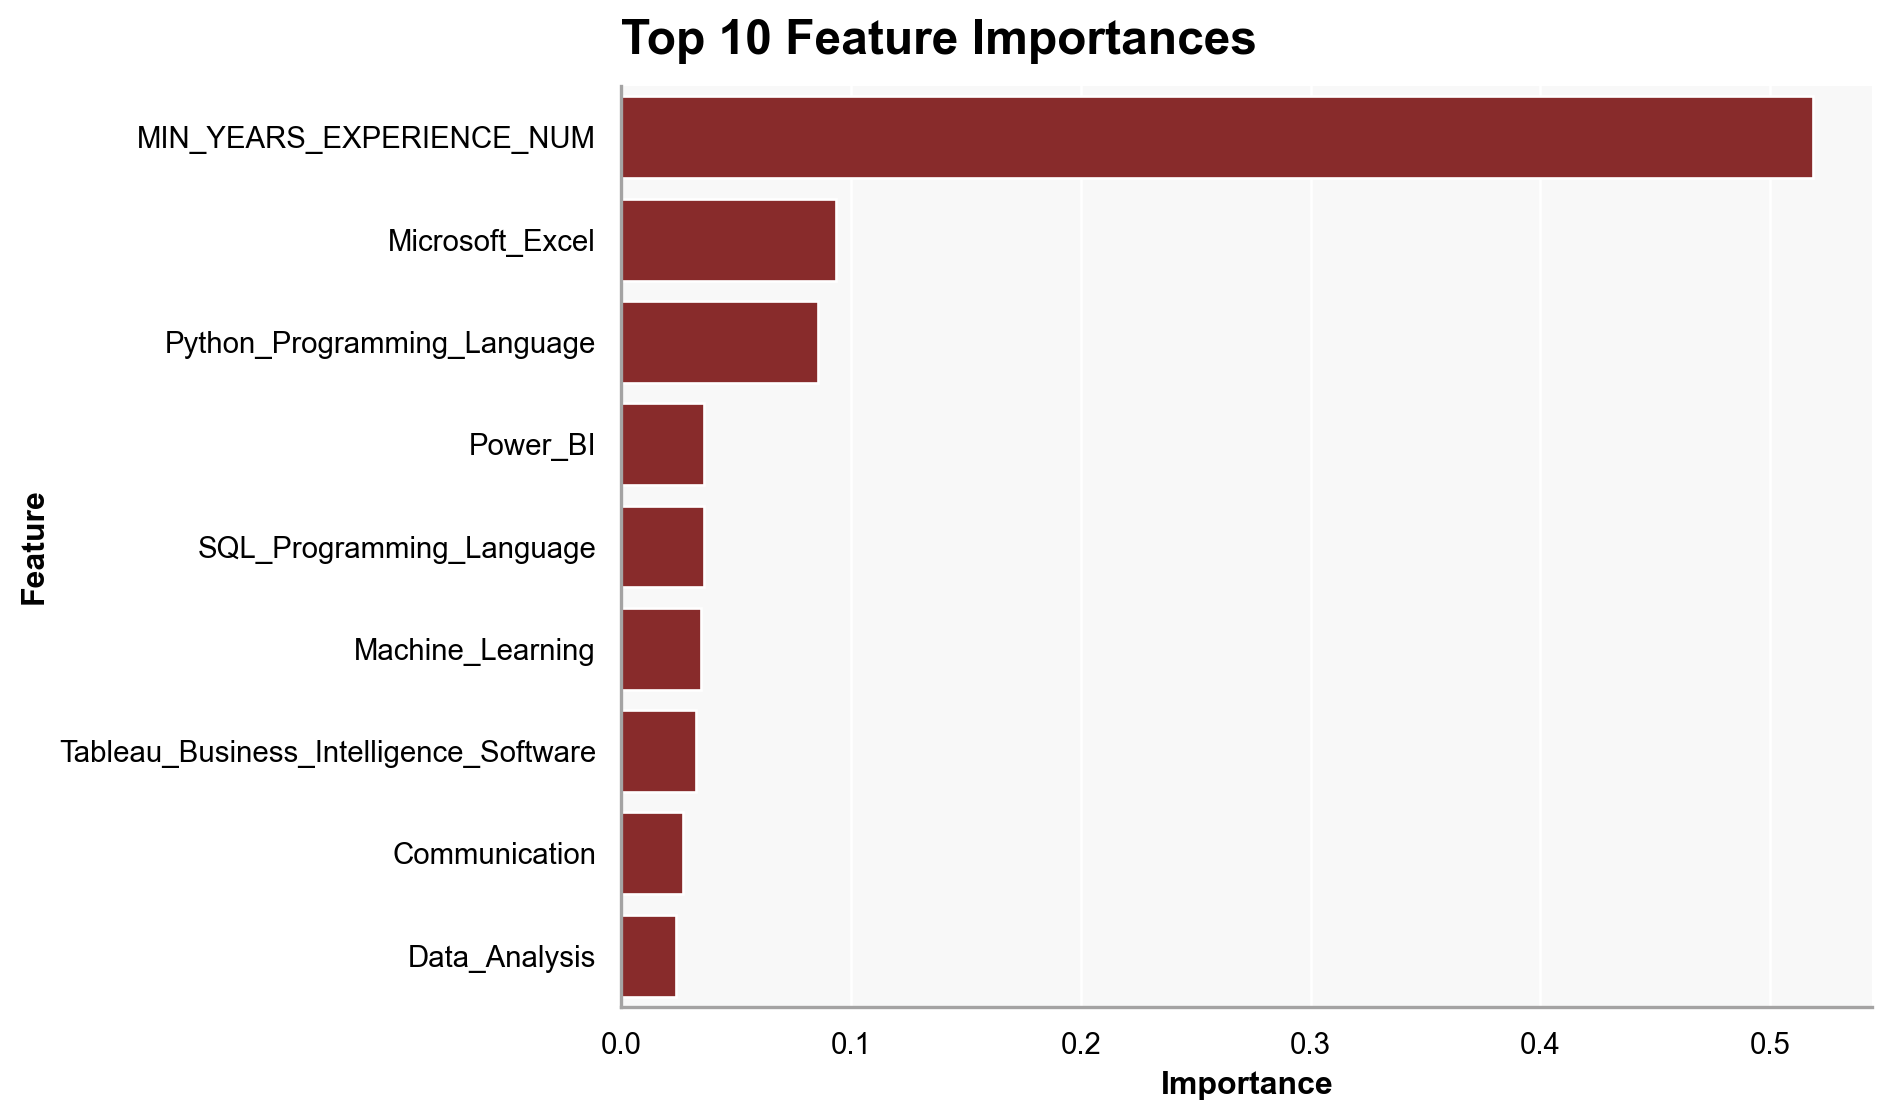

In [22]:
#| echo: true
#| eval: true
#| warning: false
import matplotlib.pyplot as plt
import seaborn as sns
top10_rf_clean = rf_importance_df[
    ~rf_importance_df["Feature"].str.contains("encoded_category")
].head(10)

top10_rf_clean = rf_importance_df[
    ~rf_importance_df["Feature"].str.contains("encoded_category")
].head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top10_rf_clean,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances", loc="left")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("images/rf_feature_importance_v2.png", dpi=300)
plt.show()

In [23]:
#| echo: true
#| eval: false
#| warning: false
cluster_features = [
    "Python_Programming_Language",
    "SQL_Programming_Language",
    "Microsoft_Excel",
    "Data_Analysis",
    "Machine_Learning",
    "Power_BI",
    "Tableau_Business_Intelligence_Software",
    "Communication"
]

df_cluster_ready = df_analysis.select(
    "ONET_NAME",
    "SPECIALIZED_OCCUPATION",
    *cluster_features
).dropna(subset=["ONET_NAME"])

df_cluster_ready.show(5, truncate=False)
print("Rows ready for clustering:", df_cluster_ready.count())

In [24]:
#| echo: true
#| eval: false
#| warning: false
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=cluster_features,
    outputCol="features"
)

cluster_data = assembler.transform(df_cluster_ready)

cluster_data.select("ONET_NAME", "SPECIALIZED_OCCUPATION", "features").show(5, truncate=False)

In [25]:
#| echo: true
#| eval: false
#| warning: false
from pyspark.ml.clustering import KMeans

kmeans = KMeans(
    featuresCol="features",
    predictionCol="cluster",
    k=3,
    seed=42
)

kmeans_model = kmeans.fit(cluster_data)

cluster_predictions = kmeans_model.transform(cluster_data)

cluster_predictions.select(
    "SPECIALIZED_OCCUPATION",
    "ONET_NAME",
    "cluster"
).show(15, truncate=False)

In [26]:
#| echo: true
#| eval: false
#| warning: false
from pyspark.ml.evaluation import ClusteringEvaluator

evaluator = ClusteringEvaluator(
    featuresCol="features",
    predictionCol="cluster",
    metricName="silhouette"
)

silhouette = evaluator.evaluate(cluster_predictions)

print("Silhouette Score:", silhouette)

In [27]:
#| echo: true
#| eval: false
#| warning: false
cluster_onet = cluster_predictions.groupBy("cluster", "ONET_NAME") \
    .count() \
    .orderBy("cluster", F.col("count").desc())

cluster_onet.show(30, truncate=False)

In [28]:
#| echo: true
#| eval: false
#| warning: false
centers = kmeans_model.clusterCenters()

for i, center in enumerate(centers):
    print(f"Cluster {i} center:")
    for feature_name, value in zip(cluster_features, center):
        print(f"  {feature_name}: {round(float(value), 3)}")

In [29]:
#| echo: true
#| eval: false
#| warning: false
from pyspark.ml.feature import PCA

pca = PCA(k=2, inputCol="features", outputCol="pcaFeatures")
pca_model = pca.fit(cluster_predictions)
pca_result = pca_model.transform(cluster_predictions)

pca_pd = pca_result.select(
    "cluster",
    "SPECIALIZED_OCCUPATION",
    "ONET_NAME",
    "pcaFeatures"
).toPandas()

pca_pd["PC1"] = pca_pd["pcaFeatures"].apply(lambda v: float(v[0]))
pca_pd["PC2"] = pca_pd["pcaFeatures"].apply(lambda v: float(v[1]))

pca_pd.head()

In [30]:
#| echo: true
#| eval: false
#| warning: false
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_pd,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette=["#DC1212", "#FA8072", "#8B0000"],
    s=70,
    alpha=0.65,
)

plt.title("K-Means Clusters Based on Skills",loc="left")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("./images/kmeans_clusters.png", dpi=300)
plt.show()

In [31]:
#| echo: true
#| eval: false
#| warning: false
cluster_counts_pd = (
    cluster_predictions.groupBy("cluster")
    .count()
    .orderBy("cluster")
    .toPandas()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=cluster_counts_pd, x="cluster", y="count")

plt.title("Number of Job Postings in Each Cluster", loc="left")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("./images/cluster_counts.png", dpi=300)
plt.show()